# PIDNet — final paper results

This notebook is the presentation layer for the final flood-segmentation experiments. It inventories global concepts, computes layer-wise deletion AOC and insertion AUC directly from saved tensors, and links/displays the final figures. It does not train or rerun PIDNet.

> Run all cells from top to bottom. Change only the configuration cell when moving the results directory or selecting a different final relevance initialization.

In [9]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Markdown, display

NOTEBOOK_DIR = Path.cwd() if (Path.cwd() / 'paper_results_utils.py').exists() else Path.cwd() / 'notebooks'
sys.path.insert(0, str(NOTEBOOK_DIR.resolve()))
from paper_results_utils import *
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 100)

## Configuration

In [10]:
REPO_ROOT = find_repo_root()
RESULTS_ROOT = resolve_results_root(REPO_ROOT)  # or set PAPER_RESULTS_DIR before starting Jupyter
DATASET = 'flood'
MODEL = 'pidnet'
RUN = 'logits'  # available alternatives are listed below, commonly 'ones' and 'prob'
OUTPUT_DIR = REPO_ROOT / 'paper output' / 'pidnet'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Repository: {REPO_ROOT}')
print(f'Results:    {RESULTS_ROOT}')
print(f'Exports:    {OUTPUT_DIR}')

Repository: /home/heydari/paper/Segmentation-and-Object-detection-PCX
Results:    /home/heydari/paper/12-supp/code/results
Exports:    /home/heydari/paper/Segmentation-and-Object-detection-PCX/paper output/pidnet


## Result completeness

In [11]:
model_root = RESULTS_ROOT / 'instance_perturbation' / DATASET / MODEL
display(Markdown(f'**Available perturbation runs:** {", ".join(sorted(p.name for p in model_root.iterdir() if p.is_dir())) if model_root.is_dir() else "none"}'))
artifact_table = artifact_inventory(RESULTS_ROOT)
concept_table = concept_inventory(RESULTS_ROOT, DATASET, MODEL)
display(artifact_table)
display(concept_table)
artifact_table.to_csv(OUTPUT_DIR / 'PIDNet_artifact_inventory.csv', index=False)
concept_table.to_csv(OUTPUT_DIR / 'PIDNet_concept_inventory.csv', index=False)

**Available perturbation runs:** logits, logits_onlyflood, ones, ones_only_flood, ones_onlyflood, prob

,format,files,size_MB
0,.pth,4496,3117.648905
1,.pdf,2881,88.410522
2,.png,226,55.646190
3,.json,59,1.944530
4,.txt,19,0.038050
5,.log,10,42.609924
6,.md,8,0.017850
7,.ipynb,1,0.000230


,initialization,class,layer_files
0,logits,0,79
1,logits,1,79
2,ones,0,79
3,ones,1,79
4,prob,0,79
5,prob,1,79


## Faithfulness results

Higher values indicate stronger effects for both reported reductions: deletion is sign-adjusted to AOC, while insertion is baseline-adjusted AUC. Error bars below are standard errors across samples.

In [12]:
summary_all = load_perturbation_summary(RESULTS_ROOT, DATASET, MODEL, RUN)
display(perturbation_diagnostics(RESULTS_ROOT, DATASET, MODEL, RUN, summary_all))
summary = summary_all[summary_all['layer'].isin(PIDNET_POST_MERGE_LAYERS)].copy()
print(f'Loaded {len(summary):,} method/layer/mode records from {summary.layer.nunique() if not summary.empty else 0} layers.')
display(score_table(summary))

,selected_directory,directory_exists,available_runs,candidate_pth_files,successfully_decoded_files,load_errors,first_load_error
0,/home/heydari/paper/12-supp/code/results/instance_perturbation/flood/pidnet/logits,True,"logits, logits_onlyflood, ones, ones_only_flood, ones_onlyflood, prob",112,112,0,


Loaded 56 method/layer/mode records from 4 layers.


,mode,method,mean_score,layers,samples
0,Deletion AOC,LRP-epsilon,1.065534,4,100
1,Deletion AOC,LRP-gamma,1.056024,4,100
2,Deletion AOC,GradCAM,0.884050,4,100
3,Deletion AOC,LRP-z+,0.841349,4,100
4,Deletion AOC,Gradient,0.828280,4,100
5,Deletion AOC,Activation,0.551385,4,100
6,Deletion AOC,Random,0.354731,4,100
7,Insertion AUC,LRP-epsilon,1.089569,4,100
8,Insertion AUC,LRP-gamma,1.078250,4,100
9,Insertion AUC,GradCAM,0.902439,4,100


Saved exact post-merge plots to /home/heydari/paper/Segmentation-and-Object-detection-PCX/paper output


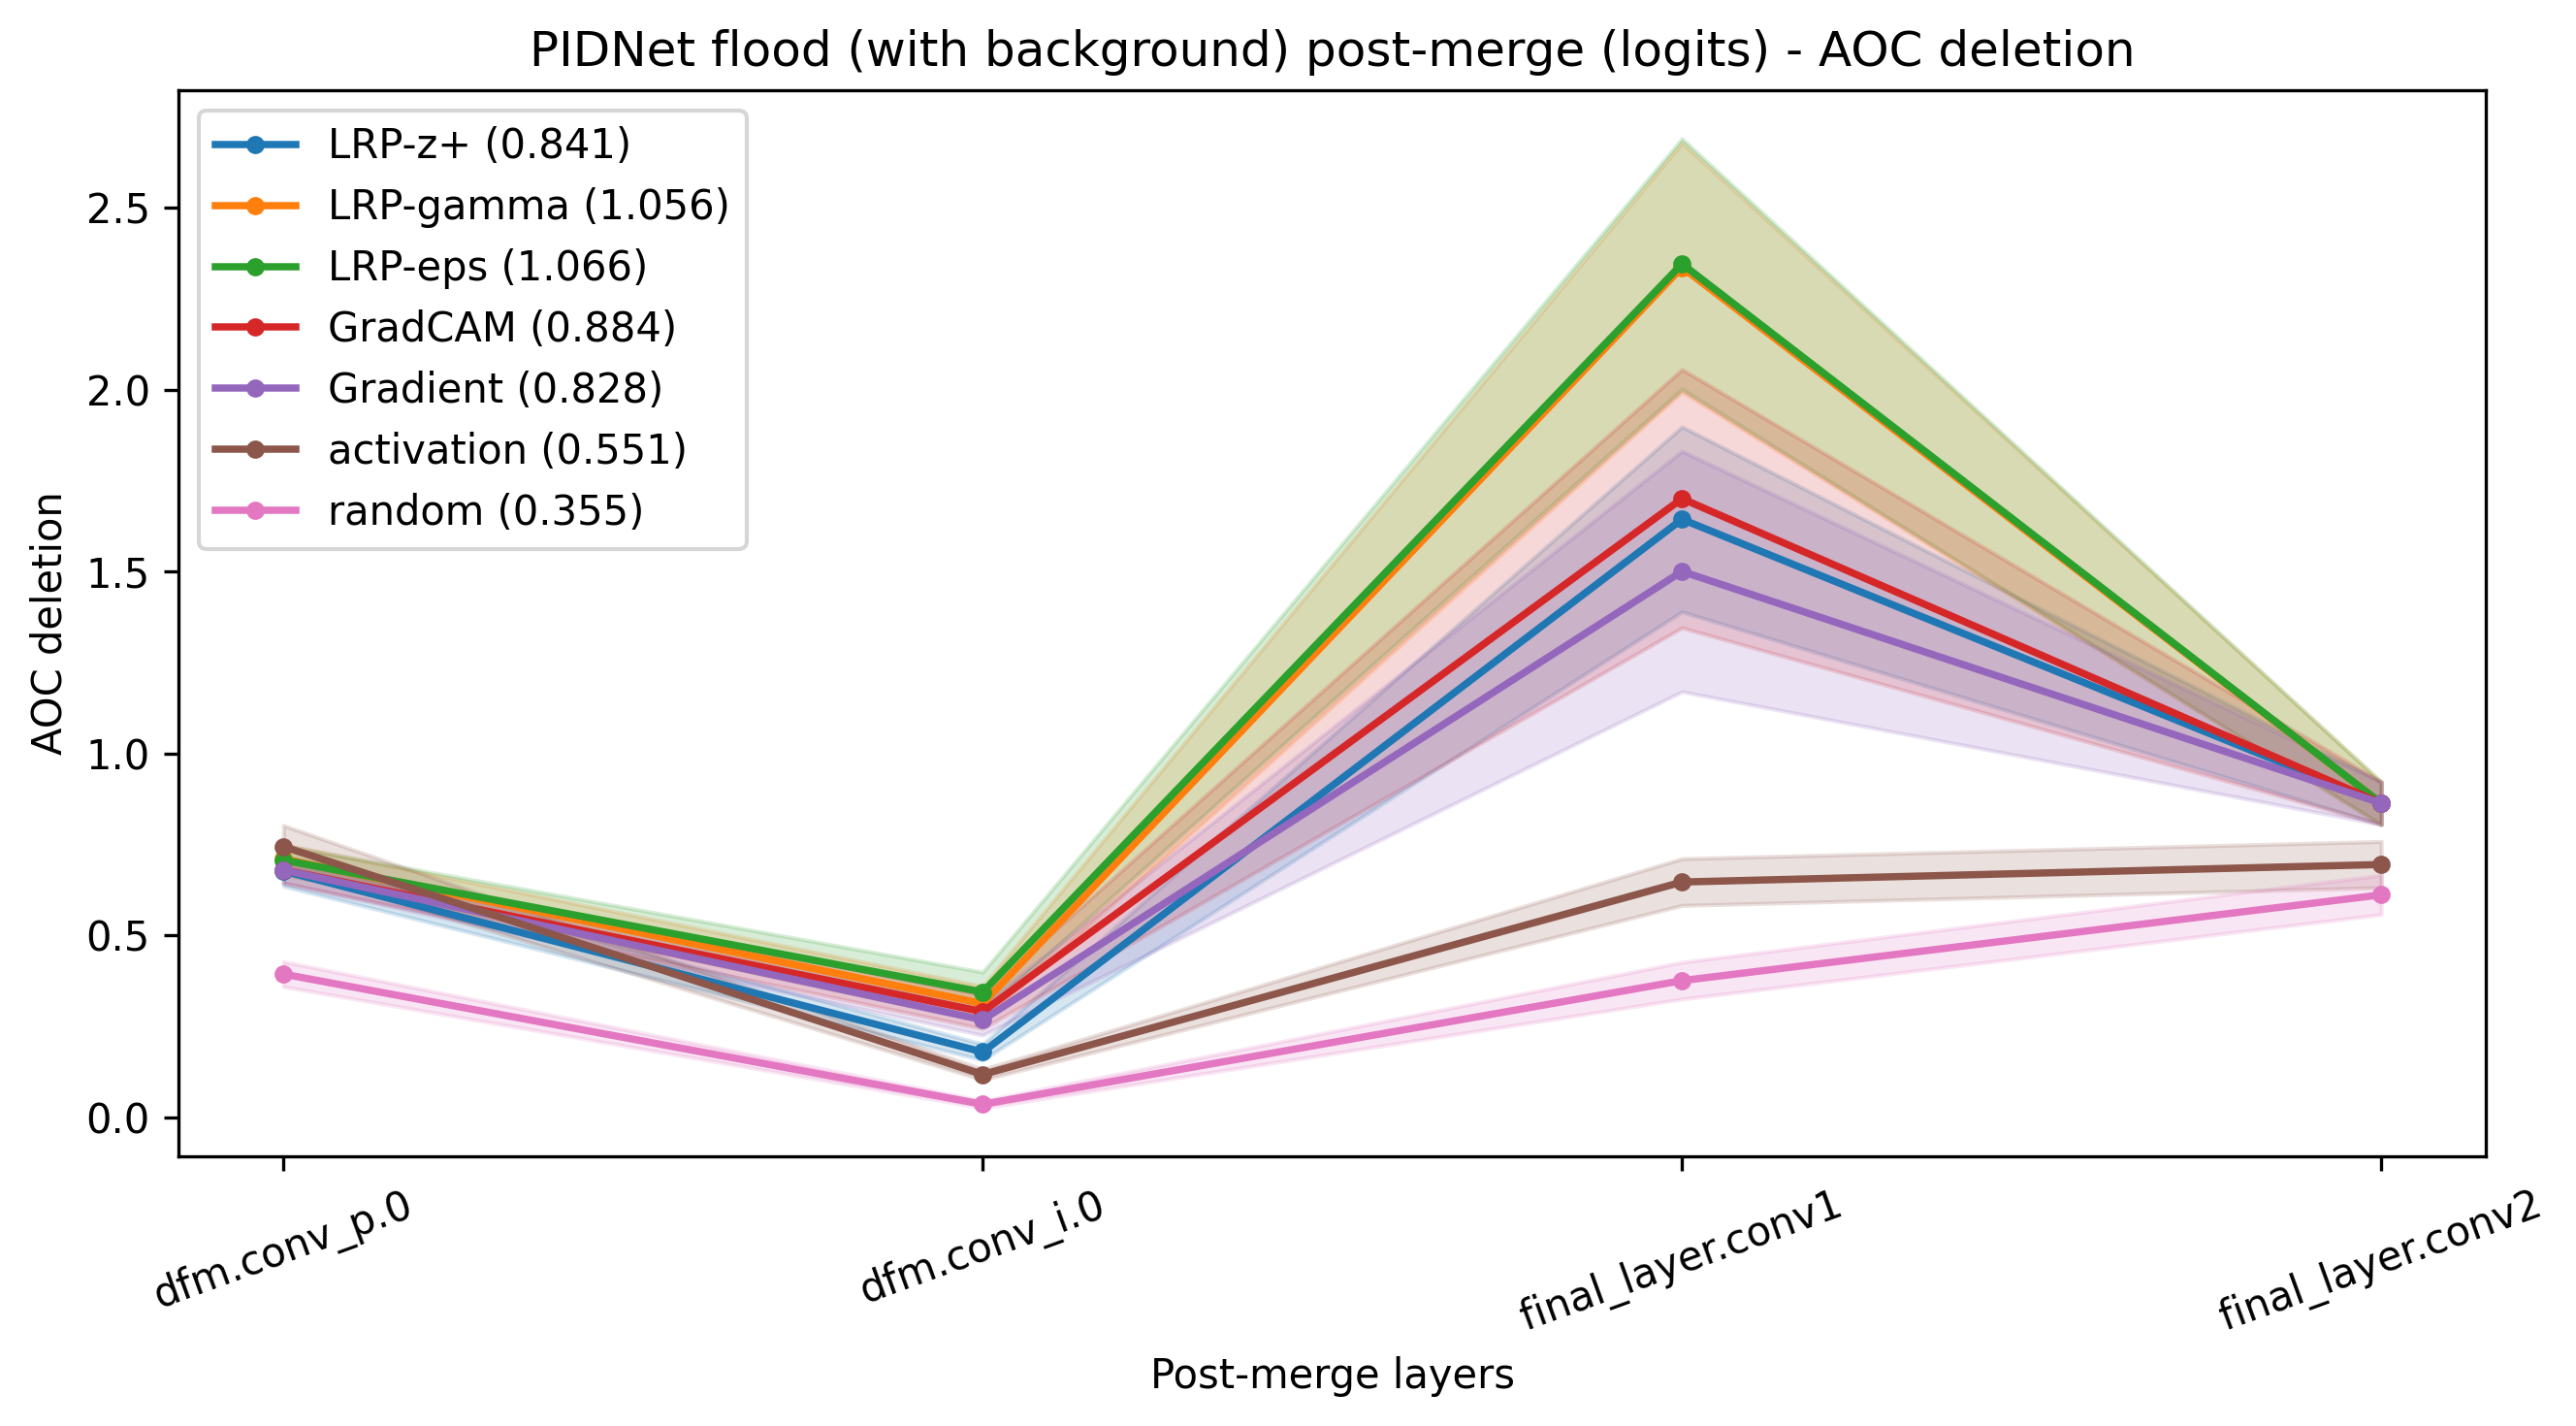

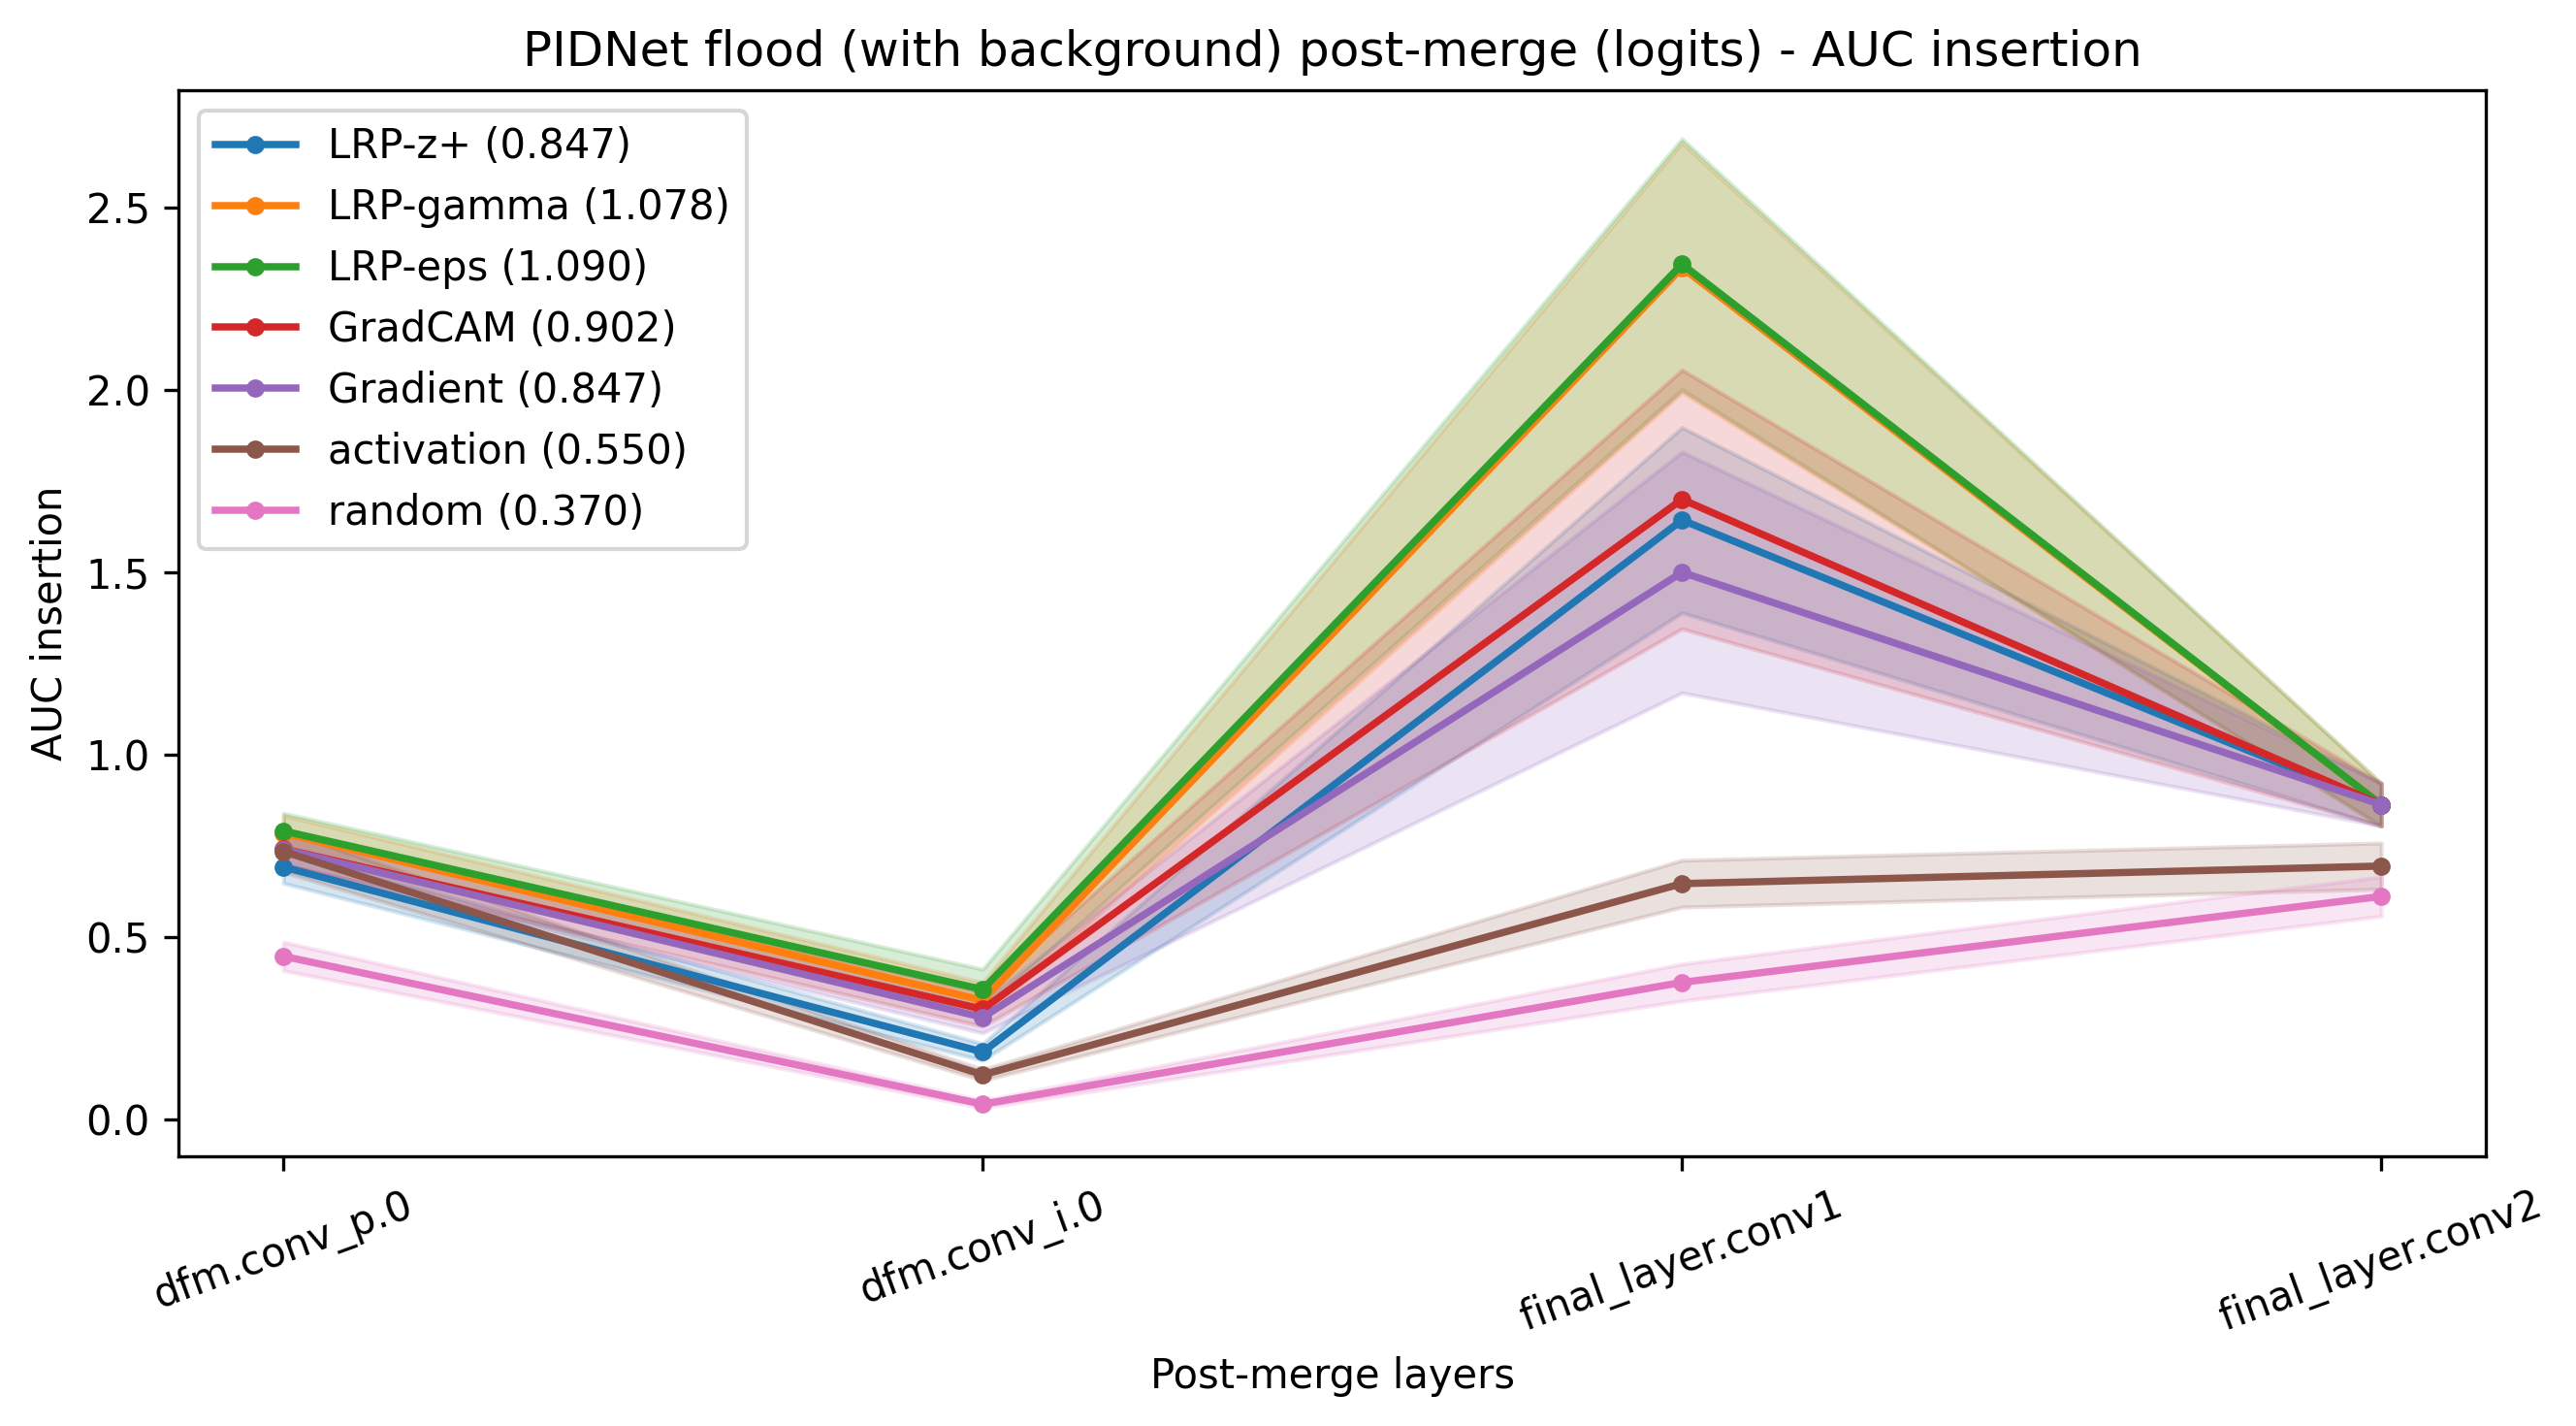

In [13]:
PAPER_OUTPUT_DIR = REPO_ROOT / 'paper output'
deletion_figure = plot_pidnet_post_merge(RESULTS_ROOT, RUN, insertion=False)
insertion_figure = plot_pidnet_post_merge(RESULTS_ROOT, RUN, insertion=True)
deletion_figure.savefig(PAPER_OUTPUT_DIR / 'concept_perturbation_pidnet_with_background_deletion.pdf', dpi=300, bbox_inches='tight', transparent=True)
insertion_figure.savefig(PAPER_OUTPUT_DIR / 'concept_perturbation_pidnet_with_background_insertion.pdf', dpi=300, bbox_inches='tight', transparent=True)
deletion_figure.savefig(OUTPUT_DIR / 'PIDNet_post_merge_deletion.png', dpi=300, bbox_inches='tight')
insertion_figure.savefig(OUTPUT_DIR / 'PIDNet_post_merge_insertion.png', dpi=300, bbox_inches='tight')
print(f'Saved exact post-merge plots to {PAPER_OUTPUT_DIR}')

## Paper-selected PIDNet outputs

The final with-background deletion and insertion plots are embedded directly from `paper output`.

In [14]:
PAPER_OUTPUT_DIR = REPO_ROOT / 'paper output'
selected_pidnet_plots = [
    PAPER_OUTPUT_DIR / 'concept_perturbation_pidnet_with_background_deletion.pdf',
    PAPER_OUTPUT_DIR / 'concept_perturbation_pidnet_with_background_insertion.pdf',
]
display_pdf_plots(selected_pidnet_plots)

### Concept Perturbation Pidnet With Background Deletion

### Concept Perturbation Pidnet With Background Insertion

## Final rendered figures

In [15]:
figure_root = RESULTS_ROOT / 'instance_perturbation' / DATASET / MODEL / RUN
figures = final_figures(figure_root, keywords=('summary', 'concept_perturbation', 'insertion'), limit=24)
print(f'{len(figures)} prioritized figures (change keywords/limit to show more).')
display_gallery(figures)
figure_manifest = export_figure_artifacts(figures, OUTPUT_DIR)
display(figure_manifest)

24 prioritized figures (change keywords/limit to show more).


**pag_plus_postmerge_summary_logits_aoc.pdf**  
`/home/heydari/paper/12-supp/code/results/instance_perturbation/flood/pidnet/logits/data/pag_plus_postmerge_summary_logits_aoc.pdf`

[Open PDF](file:///home/heydari/paper/12-supp/code/results/instance_perturbation/flood/pidnet/logits/data/pag_plus_postmerge_summary_logits_aoc.pdf)

**pag_plus_postmerge_summary_logits_auc.pdf**  
`/home/heydari/paper/12-supp/code/results/instance_perturbation/flood/pidnet/logits/data/pag_plus_postmerge_summary_logits_auc.pdf`

[Open PDF](file:///home/heydari/paper/12-supp/code/results/instance_perturbation/flood/pidnet/logits/data/pag_plus_postmerge_summary_logits_auc.pdf)

...

**instance_perturbation_layer2.0.downsample.0_insertion.pdf**  
`/home/heydari/paper/12-supp/code/results/instance_perturbation/flood/pidnet/logits/instance_perturbation_layer2.0.downsample.0_insertion.pdf`

[Open PDF](file:///home/heydari/paper/12-supp/code/results/instance_perturbation/flood/pidnet/logits/instance_perturbation_layer2.0.downsample.0_insertion.pdf)

**instance_perturbation_layer2.1.conv1_insertion.pdf**  
`/home/heydari/paper/12-supp/code/results/instance_perturbation/flood/pidnet/logits/instance_perturbation_layer2.1.conv1_insertion.pdf`

[Open PDF](file:///home/heydari/paper/12-supp/code/results/instance_perturbation/flood/pidnet/logits/instance_perturbation_layer2.1.conv1_insertion.pdf)

,source,exported_to
0,/home/heydari/paper/12-supp/code/results/instance_perturbation/flood/pidnet/logits/data/pag_plus...,/home/heydari/paper/Segmentation-and-Object-detection-PCX/paper output/pidnet/source_figures/001...
1,/home/heydari/paper/12-supp/code/results/instance_perturbation/flood/pidnet/logits/data/pag_plus...,/home/heydari/paper/Segmentation-and-Object-detection-PCX/paper output/pidnet/source_figures/002...
2,/home/heydari/paper/12-supp/code/results/instance_perturbation/flood/pidnet/logits/data/pag_plus...,/home/heydari/paper/Segmentation-and-Object-detection-PCX/paper output/pidnet/source_figures/003...
3,/home/heydari/paper/12-supp/code/results/instance_perturbation/flood/pidnet/logits/data/post_mer...,/home/heydari/paper/Segmentation-and-Object-detection-PCX/paper output/pidnet/source_figures/004...
4,/home/heydari/paper/12-supp/code/results/instance_perturbation/flood/pidnet/logits/data/post_mer...,/home/heydari/paper/Segmentation-and-Object-detection-PCX/paper output/pidnet/source_figures/005...
5,/home/heydari/paper/12-supp/code/results/instance_perturbation/flood/pidnet/logits/data/post_mer...,/home/heydari/paper/Segmentation-and-Object-detection-PCX/paper output/pidnet/source_figures/006...
6,/home/heydari/paper/12-supp/code/results/instance_perturbation/flood/pidnet/logits/instance_pert...,/home/heydari/paper/Segmentation-and-Object-detection-PCX/paper output/pidnet/source_figures/007...
7,/home/heydari/paper/12-supp/code/results/instance_perturbation/flood/pidnet/logits/instance_pert...,/home/heydari/paper/Segmentation-and-Object-detection-PCX/paper output/pidnet/source_figures/008...
8,/home/heydari/paper/12-supp/code/results/instance_perturbation/flood/pidnet/logits/instance_pert...,/home/heydari/paper/Segmentation-and-Object-detection-PCX/paper output/pidnet/source_figures/009...
9,/home/heydari/paper/12-supp/code/results/instance_perturbation/flood/pidnet/logits/instance_pert...,/home/heydari/paper/Segmentation-and-Object-detection-PCX/paper output/pidnet/source_figures/010...


## Export the summary table

The CSV is written automatically to the configured output directory.

In [16]:
final_table = score_table(summary)
display(final_table)
final_table.to_csv(OUTPUT_DIR / 'PIDNet_final_results.csv', index=False)
summary.to_csv(OUTPUT_DIR / 'PIDNet_layer_results.csv', index=False)
print(f'Complete PIDNet result bundle: {OUTPUT_DIR}')

,mode,method,mean_score,layers,samples
0,Deletion AOC,LRP-epsilon,1.065534,4,100
1,Deletion AOC,LRP-gamma,1.056024,4,100
2,Deletion AOC,GradCAM,0.884050,4,100
3,Deletion AOC,LRP-z+,0.841349,4,100
4,Deletion AOC,Gradient,0.828280,4,100
5,Deletion AOC,Activation,0.551385,4,100
6,Deletion AOC,Random,0.354731,4,100
7,Insertion AUC,LRP-epsilon,1.089569,4,100
8,Insertion AUC,LRP-gamma,1.078250,4,100
9,Insertion AUC,GradCAM,0.902439,4,100


Complete PIDNet result bundle: /home/heydari/paper/Segmentation-and-Object-detection-PCX/paper output/pidnet
